In [1]:
import numpy as np
from numba import jit, njit
import pandas as pd

## Part I

Дан массив A размера (X, Y, Z) -- к примеру, (1000, 1000, 30). Отдельный элемент A[i, j, :] назовем трассой из A.
дан второй массив B размера (N, Z) -- несколько трасс. Необходимо для каждой трассы из A посчитать среднее значение корреляции между A[i, j, :] и всеми трассами из B. Примерное значение N -- от 20 до 100


### Some notes

In [2]:
A = np.random.randn(1000, 1000, 30)

In [3]:
%%timeit
u = np.zeros_like(A)

51.7 ms ± 110 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [4]:
%%timeit
u = np.zeros((A.shape[:2]))

296 µs ± 2.82 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [5]:
%%timeit
u = np.empty_like(A)

5.95 µs ± 420 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


In [6]:
%%timeit
u = np.empty((A.shape[:2]))

536 ns ± 3.48 ns per loop (mean ± std. dev. of 7 runs, 1000000 loops each)


In [7]:
x = np.random.randn(1000000)
y = np.random.randn(1000000) 

In [8]:
%%time
x @ y 

CPU times: user 39.4 ms, sys: 391 ms, total: 430 ms
Wall time: 8.85 ms


261.14824081050386

In [9]:
%%time
(x * y).sum()

CPU times: user 27.6 ms, sys: 217 ms, total: 245 ms
Wall time: 4.16 ms


261.1482408105055

### Solutions via for loop (slow)

In [10]:
def average_correlation_slow(A, B):
    """ Original function """
    X, Y, Z = A.shape # 1000 x 1000 x 30
    mean_corr_for_traces = np.empty((X, Y))
    B_normalized = (B - B.mean(axis=-1, keepdims=True)) / B.std(axis=-1, keepdims=True)
    
    for i in range(X):
        for j in range(Y):
            res = np.mean((A[i, j] - A[i, j].mean()) * B_normalized, axis=-1) / A[i, j].std()
            mean_corr_for_traces[i, j] = np.mean(res)
    
    return mean_corr_for_traces

In [11]:
def average_correlation_slow_trace(A, B):
    """ Call __getitem__() only once for each trace in for loop """
    X, Y, Z = A.shape # 1000 x 1000 x 30
    mean_corr_for_traces = np.empty((X, Y))
    B_normalized = (B - B.mean(axis=-1, keepdims=True)) / B.std(axis=-1, keepdims=True)
    
    for i in range(X):
        for j in range(Y):
            trace = A[i, j]
            res = np.mean((trace - trace.mean()) * B_normalized, axis=-1) / trace.std()
            mean_corr_for_traces[i, j] = np.mean(res)
    
    return mean_corr_for_traces

In [12]:
def average_correlation_slow_prenormalized(A, B):
    """ Pre-normalized matrix A """
    X, Y, Z = A.shape # 1000 x 1000 x 30
    mean_corr_for_traces = np.empty((X, Y))
    B_normalized = (B - B.mean(axis=-1, keepdims=True)) / B.std(axis=-1, keepdims=True)
    A_normalized = (A - A.mean(axis=-1, keepdims=True)) / A.std(axis=-1, keepdims=True)
    
    for i in range(X):
        for j in range(Y):
            trace = A_normalized[i, j]
            res = np.mean(trace * B_normalized, axis=-1)
            mean_corr_for_traces[i, j] = np.mean(res)
    
    return mean_corr_for_traces

In [13]:
def average_correlation_slow_trace_matmul(A, B):
    """ Matrix mul in for loop """
    X, Y, Z = A.shape # 1000 x 1000 x 30
    mean_corr_for_traces = np.empty((X, Y))
    B_normalized = (B - B.mean(axis=-1, keepdims=True)) / B.std(axis=-1, keepdims=True)
    A_normalized = (A - A.mean(axis=-1, keepdims=True)) / A.std(axis=-1, keepdims=True)
    
    for i in range(X):
        for j in range(Y):
            trace = A_normalized[i, j]
            res = 1 / Z * trace @ B_normalized.T
            mean_corr_for_traces[i, j] = np.mean(res)
    
    return mean_corr_for_traces

In [14]:
@njit
def average_correlation_numba(A, B):
    """ Numba is used. Since numba doesn't support np.mean(axis=-1), mean was realized via for loop """
    X, Y, Z = A.shape # 1000 x 1000 x 30
    N = B.shape[0]
    
    B_mean = np.empty(N)
    B_std = np.empty(N)
    for i in range(N):
        B_mean[i] = np.mean(B[i, :])
        B_std[i] = np.std(B[i, :])
    
    B_mean = B_mean.reshape(-1, 1)
    B_std = B_std.reshape(-1, 1)
    B_normalized = (B - B_mean) / B_std
    
    mean_corr_for_traces = np.empty((X, Y))
    for i in range(X):
        for j in range(Y):
            trace = A[i, j]
            trace_normalized = (trace - trace.mean()) / trace.std()
            mul = trace_normalized * B_normalized
            
            running_mean = np.empty(N)
            for k in range(N):
                running_mean[k] = np.mean(mul[k, :])
    
            mean_corr_for_traces[i, j] = np.mean(running_mean)
    
    return mean_corr_for_traces

In [15]:
def average_correlation_without_numba(A, B):
    """ The same function as in the numba case but without numba njit decorator """
    X, Y, Z = A.shape # 1000 x 1000 x 30
    N = B.shape[0]
    
    B_mean = np.empty(B.shape[0])
    B_std = np.empty(B.shape[0])
    for i in range(B.shape[0]):
        B_mean[i] = np.mean(B[i, :])
        B_std[i] = np.std(B[i, :])
    
    B_mean = B_mean.reshape(-1, 1)
    B_std = B_std.reshape(-1, 1)
    B_normalized = (B - B_mean) / B_std
    
    mean_corr_for_traces = np.empty((X, Y))
    for i in range(X):
        for j in range(Y):
            trace = A[i, j]
            trace_normalized = (trace - trace.mean()) / trace.std()
            mul = trace_normalized * B_normalized
            
            running_mean = np.empty(N)
            for k in range(N):
                running_mean[k] = np.mean(mul[k, :])
    
            mean_corr_for_traces[i, j] = np.mean(running_mean)
    
    return mean_corr_for_traces

### Vectorized solution (fast)

In [16]:
def average_correlation(A, B):
    """ For each trace in the trace matrix A computes mean correlation with each trace in trace matrix B
    
    Parameters 
    ----------
    A: np.ndarray, shape = (X, Y, Z)
        First trace matrix. Matrix A has X * Y traces.
    B: np.ndarray, shape = (N, Z)
        Second trace matrix.
        
    Returns
    -------
    correlation_matrix: np.ndarray, shape = (X, Y)
        Matrix with mean values of correlation for each trace in A. 
    """
    X, Y, Z = A.shape # 1000 x 1000 x 30
    A_reshaped = A.reshape(X * Y, -1)
    
    # normalize matrices to compute correaltions
    A_normalized = (A_reshaped - A_reshaped.mean(axis=-1, keepdims=True)) / A_reshaped.std(axis=-1, keepdims=True)
    B_normalized = (B - B.mean(axis=-1, keepdims=True)) / B.std(axis=-1, keepdims=True)
    
    # compute correlation for each trace in A matrix (we have X * Y traces)
    correlation_matrix = np.mean(1 / Z * A_normalized @ B_normalized.T, axis=-1).reshape(X, -1) # shape = (X, Y)
    
    return correlation_matrix

### Trials

In [17]:
A = np.random.randn(1000, 1000, 30)
#A = np.random.randn(7, 7, 30)

### Let's compare slow and fast solutions with N = 20

In [18]:
N = 20
B = np.random.randn(N, 30)

In [19]:
output_slow_time = %timeit -o average_correlation_slow(A, B)

39.3 s ± 444 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [20]:
output_slow = average_correlation_slow(A, B)
print(output_slow.shape)
output_slow

(1000, 1000)


array([[ 0.04304211,  0.0042633 , -0.04055211, ..., -0.01935276,
        -0.02405096, -0.01193614],
       [ 0.03748693,  0.00072719,  0.06757847, ..., -0.06785156,
        -0.03797648,  0.00551516],
       [ 0.01972599,  0.01173807,  0.03997975, ..., -0.0383346 ,
        -0.06333852, -0.01464885],
       ...,
       [ 0.00346477, -0.02130937, -0.02369948, ...,  0.01905663,
        -0.03606676, -0.01667903],
       [-0.07599069,  0.07933862,  0.0157383 , ..., -0.04192822,
        -0.0146965 ,  0.07626008],
       [-0.01154133, -0.02041226,  0.02781603, ..., -0.00525094,
         0.04053779, -0.05988032]])

In [21]:
output_slow_trace_time = %timeit -o average_correlation_slow(A, B)

39.2 s ± 227 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [22]:
output_slow_trace = average_correlation_slow_trace(A, B)
print(output_slow_trace.shape)
output_slow_trace

(1000, 1000)


array([[ 0.04304211,  0.0042633 , -0.04055211, ..., -0.01935276,
        -0.02405096, -0.01193614],
       [ 0.03748693,  0.00072719,  0.06757847, ..., -0.06785156,
        -0.03797648,  0.00551516],
       [ 0.01972599,  0.01173807,  0.03997975, ..., -0.0383346 ,
        -0.06333852, -0.01464885],
       ...,
       [ 0.00346477, -0.02130937, -0.02369948, ...,  0.01905663,
        -0.03606676, -0.01667903],
       [-0.07599069,  0.07933862,  0.0157383 , ..., -0.04192822,
        -0.0146965 ,  0.07626008],
       [-0.01154133, -0.02041226,  0.02781603, ..., -0.00525094,
         0.04053779, -0.05988032]])

In [23]:
output_slow_trace_matmul_time = %timeit -o average_correlation_slow_trace_matmul(A, B)

9.4 s ± 133 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [24]:
output_slow_trace_matmul = average_correlation_slow_trace_matmul(A, B)
print(output_slow_trace_matmul.shape)
output_slow_trace_matmul

(1000, 1000)


array([[ 0.04304211,  0.0042633 , -0.04055211, ..., -0.01935276,
        -0.02405096, -0.01193614],
       [ 0.03748693,  0.00072719,  0.06757847, ..., -0.06785156,
        -0.03797648,  0.00551516],
       [ 0.01972599,  0.01173807,  0.03997975, ..., -0.0383346 ,
        -0.06333852, -0.01464885],
       ...,
       [ 0.00346477, -0.02130937, -0.02369948, ...,  0.01905663,
        -0.03606676, -0.01667903],
       [-0.07599069,  0.07933862,  0.0157383 , ..., -0.04192822,
        -0.0146965 ,  0.07626008],
       [-0.01154133, -0.02041226,  0.02781603, ..., -0.00525094,
         0.04053779, -0.05988032]])

In [25]:
output_slow_prenormalized_time = %timeit -o average_correlation_slow_prenormalized(A, B)

16.5 s ± 49.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [26]:
output_slow_prenormalized = average_correlation_slow_prenormalized(A, B)
print(output_slow_prenormalized.shape)
output_slow_prenormalized

(1000, 1000)


array([[ 0.04304211,  0.0042633 , -0.04055211, ..., -0.01935276,
        -0.02405096, -0.01193614],
       [ 0.03748693,  0.00072719,  0.06757847, ..., -0.06785156,
        -0.03797648,  0.00551516],
       [ 0.01972599,  0.01173807,  0.03997975, ..., -0.0383346 ,
        -0.06333852, -0.01464885],
       ...,
       [ 0.00346477, -0.02130937, -0.02369948, ...,  0.01905663,
        -0.03606676, -0.01667903],
       [-0.07599069,  0.07933862,  0.0157383 , ..., -0.04192822,
        -0.0146965 ,  0.07626008],
       [-0.01154133, -0.02041226,  0.02781603, ..., -0.00525094,
         0.04053779, -0.05988032]])

In [27]:
output_fast_time = %timeit -o average_correlation(A, B)

511 ms ± 28.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [28]:
output_fast = average_correlation(A, B)
print(output_fast.shape)
output_fast

(1000, 1000)


array([[ 0.04304211,  0.0042633 , -0.04055211, ..., -0.01935276,
        -0.02405096, -0.01193614],
       [ 0.03748693,  0.00072719,  0.06757847, ..., -0.06785156,
        -0.03797648,  0.00551516],
       [ 0.01972599,  0.01173807,  0.03997975, ..., -0.0383346 ,
        -0.06333852, -0.01464885],
       ...,
       [ 0.00346477, -0.02130937, -0.02369948, ...,  0.01905663,
        -0.03606676, -0.01667903],
       [-0.07599069,  0.07933862,  0.0157383 , ..., -0.04192822,
        -0.0146965 ,  0.07626008],
       [-0.01154133, -0.02041226,  0.02781603, ..., -0.00525094,
         0.04053779, -0.05988032]])

In [29]:
output_numba = average_correlation_numba(A, B)
print(output_numba.shape)
output_numba

(1000, 1000)


array([[ 0.04304211,  0.0042633 , -0.04055211, ..., -0.01935276,
        -0.02405096, -0.01193614],
       [ 0.03748693,  0.00072719,  0.06757847, ..., -0.06785156,
        -0.03797648,  0.00551516],
       [ 0.01972599,  0.01173807,  0.03997975, ..., -0.0383346 ,
        -0.06333852, -0.01464885],
       ...,
       [ 0.00346477, -0.02130937, -0.02369948, ...,  0.01905663,
        -0.03606676, -0.01667903],
       [-0.07599069,  0.07933862,  0.0157383 , ..., -0.04192822,
        -0.0146965 ,  0.07626008],
       [-0.01154133, -0.02041226,  0.02781603, ..., -0.00525094,
         0.04053779, -0.05988032]])

In [30]:
output_numba_time = %timeit -o average_correlation_numba(A, B)

1.1 s ± 83.1 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [31]:
%%time
output_without_numba = average_correlation_without_numba(A, B)

CPU times: user 2min 28s, sys: 866 ms, total: 2min 29s
Wall time: 2min 28s


In [32]:
print(output_without_numba.shape)
output_without_numba

(1000, 1000)


array([[ 0.04304211,  0.0042633 , -0.04055211, ..., -0.01935276,
        -0.02405096, -0.01193614],
       [ 0.03748693,  0.00072719,  0.06757847, ..., -0.06785156,
        -0.03797648,  0.00551516],
       [ 0.01972599,  0.01173807,  0.03997975, ..., -0.0383346 ,
        -0.06333852, -0.01464885],
       ...,
       [ 0.00346477, -0.02130937, -0.02369948, ...,  0.01905663,
        -0.03606676, -0.01667903],
       [-0.07599069,  0.07933862,  0.0157383 , ..., -0.04192822,
        -0.0146965 ,  0.07626008],
       [-0.01154133, -0.02041226,  0.02781603, ..., -0.00525094,
         0.04053779, -0.05988032]])

### Results

In [33]:
np.allclose(output_slow, output_fast), \
np.allclose(output_slow_trace_matmul, output_fast), \
np.allclose(output_slow_prenormalized, output_fast), \
np.allclose(output_numba, output_fast), \
np.allclose(output_without_numba, output_fast)

(True, True, True, True, True)

In [34]:
results = pd.DataFrame(data=[output_slow_time.average, output_slow_trace_time.average,
                             output_slow_trace_matmul_time.average, output_slow_prenormalized_time.average,
                             output_numba_time.average, output_fast_time.average, 147],
                       index=['average_correlation_slow', 'average_correlation_slow_trace',
                              'average_correlation_slow_prenormalized','average_correlation_slow_trace_matmul',
                              'average_correlation', 'average_correlation_numba', 'average_correlation_without_numba'],
                       columns=['time, s'])
results = results.round(3)
results.sort_values(by='time, s', ascending=False)

,"time, s"
average_correlation_without_numba,147.000
average_correlation_slow,39.261
average_correlation_slow_trace,39.232
average_correlation_slow_trace_matmul,16.521
average_correlation_slow_prenormalized,9.401
average_correlation,1.102
average_correlation_numba,0.511


### Conclusion
Если в цикле for обращаться к каждый трассе один раз, т.е. trace = A[i, j] --> работает быстрее

Если сделать нормировку матрицы A перед циклом, а не для каждой трассы на каждой итерации --> работает быстрее

Если сделать расчет корреляции через матричное умножение, а не через умножение матриц с бродкастом --> работает быстрее

Numba значительно выйгрывает в скорости в решении через циклы

Значительное замедление по сравнению с полностью векторизованным решением дает итерирование с помощью цикла for

Numba дает хороший буст в скорости

### Fast solution with different N

In [35]:
%%time
N = 50 
B = np.random.randn(N, 30)
output = average_correlation(A, B)
print(output.shape)
output

(1000, 1000)
CPU times: user 8.11 s, sys: 5.27 s, total: 13.4 s
Wall time: 618 ms


array([[-0.03091342,  0.03459888, -0.0333479 , ...,  0.04523941,
        -0.00573617,  0.03245578],
       [-0.03552918,  0.02762961,  0.01037019, ...,  0.05382693,
        -0.01440645, -0.0187904 ],
       [ 0.00199792, -0.03976684, -0.00183433, ...,  0.0332189 ,
        -0.0218459 , -0.00549396],
       ...,
       [-0.04780719,  0.01988351,  0.02479236, ..., -0.10809143,
         0.05270058,  0.02194618],
       [ 0.01658514, -0.00683914, -0.02565942, ..., -0.0468074 ,
        -0.03525835,  0.01063593],
       [ 0.01827003,  0.03953366,  0.04027024, ...,  0.00170794,
        -0.03768908,  0.07338078]])

In [36]:
%%time
N = 70 
B = np.random.randn(N, 30)
output = average_correlation(A, B)
print(output.shape)
output

(1000, 1000)
CPU times: user 11.4 s, sys: 9.85 s, total: 21.2 s
Wall time: 712 ms


array([[ 1.06527588e-02, -1.15578928e-02,  1.32996006e-02, ...,
        -5.63524313e-03, -4.23329395e-02, -1.15383755e-02],
       [ 9.45937888e-03, -1.08731592e-02, -2.30549604e-02, ...,
         1.09379449e-02, -1.48528640e-03,  9.82668765e-03],
       [-1.45217044e-02, -6.29494259e-03, -8.03284239e-03, ...,
         2.07308515e-03,  1.40355698e-02, -1.95406329e-02],
       ...,
       [-6.59170080e-03, -2.62896075e-02, -2.37252500e-02, ...,
        -2.19306290e-02,  2.33285386e-02,  3.30251217e-03],
       [ 2.85177244e-02, -9.08060884e-03,  1.59413545e-02, ...,
         3.73588707e-03,  6.01459590e-03, -1.49943548e-02],
       [-2.68591404e-02,  2.84514359e-02, -9.84049255e-03, ...,
         8.74454287e-05, -1.61070323e-02,  9.73147111e-03]])

In [37]:
%%time
N = 100 
B = np.random.randn(N, 30)
output = average_correlation(A, B)
print(output.shape)
output

(1000, 1000)
CPU times: user 12.9 s, sys: 10.2 s, total: 23.2 s
Wall time: 785 ms


array([[ 0.01258604, -0.02401758,  0.01635698, ..., -0.00522613,
        -0.00706895,  0.0034911 ],
       [ 0.02607992,  0.01625807, -0.00572576, ...,  0.01169276,
        -0.00288118, -0.02046081],
       [ 0.00801054, -0.01027366, -0.0248768 , ..., -0.00560054,
         0.01436237,  0.0230597 ],
       ...,
       [-0.00966379, -0.01718778,  0.02791317, ..., -0.00177814,
        -0.0166019 , -0.00905555],
       [-0.02650124, -0.0036471 ,  0.00469928, ...,  0.01604165,
        -0.0260633 ,  0.00670134],
       [ 0.01615013,  0.02083733, -0.02805903, ...,  0.00559248,
        -0.01865053, -0.01178165]])

## Part II

Для квадратного окна заданного (нечетного) размера K посчитать массив output размера (X, Y), где на i,j месте находится среднее значение корреляции между трассой A[i, j, :] и всеми соседними трассами, лежащими внутри квадратного окна KxK с центром в i,j трассе. 
Примерное значение K -- от 3 до 13

### Slow solutions

In [38]:
def window_correlation(A, K):
    """ Applies sliding window to i, j trace in trace matrix A via np.corrcoef. """
    X, Y = A.shape[:2]
    output = np.empty((X, Y))
    padding = K // 2  
    # add padding to the trace matrix 
    A_pad = np.pad(A, pad_width=((padding, padding), (padding, padding), (0, 0)))
    pad_shape_x, pad_shape_y = A_pad.shape[:2]
    
    for i in range(padding, pad_shape_x - padding):
        for j in range(padding, pad_shape_y - padding):
                
            sum_corr = 0
            values_in_window = 0
            curr_trace = A_pad[i, j]
            traces_in_window = A_pad[i - padding: i + padding + 1, j - padding: j + padding + 1]
            
            for window_i in range(K):
                for window_j in range(K):

                    if window_i == K // 2 and window_j == K // 2: # don't consider the central trace with itself 
                        continue
                    
                    window_trace = traces_in_window[window_i, window_j]
                    corr_val = np.nan_to_num(np.corrcoef(curr_trace, window_trace)[0, 1])
                    sum_corr += corr_val
                    
                    if corr_val != 0:
                        values_in_window += 1
                    
            avg_corr = sum_corr / values_in_window
            output[i - padding, j - padding] = avg_corr
    
    return output 

In [39]:
def window_correlation_handy_corr(A, K):
    """ Applies sliding window to i, j trace in trace matrix A via handy correlations. """
    X, Y = A.shape[:2]
    output = np.empty((X, Y))
    padding = K // 2  
    # add padding to the trace matrix 
    A_pad = np.pad(A, pad_width=((padding, padding), (padding, padding), (0, 0)))
    pad_shape_x, pad_shape_y = A_pad.shape[:2]
    
    for i in range(padding, pad_shape_x - padding):
        for j in range(padding, pad_shape_y - padding):
        
            sum_corr = 0
            values_in_window = 0
            curr_trace = A_pad[i, j]
            traces_in_window = A_pad[i - padding: i + padding + 1, j - padding: j + padding + 1]
            
            for window_i in range(K):
                for window_j in range(K):

                    if window_i == K // 2 and window_j == K // 2: # don't consider the central trace with itself 
                        continue

                    window_trace = traces_in_window[window_i, window_j]
                    corr_val = np.nan_to_num(np.mean((curr_trace - curr_trace.mean()) * (window_trace - window_trace.mean())) \
                                / (curr_trace.std() * window_trace.std()))
                    sum_corr += corr_val

                    if corr_val != 0:
                        values_in_window += 1

            avg_corr = sum_corr / values_in_window
            output[i - padding, j - padding] = avg_corr
            
    return output

In [40]:
@njit
def window_correlation_handy_corr_numba(A, K):
    """ Applies sliding window to i, j trace in trace matrix A via handy correlations with numba. """
    X, Y, Z = A.shape
    output = np.empty((X, Y))
    # add handy padding to the trace matrix cause numba doesn't support np.pad()
    padding = K // 2
    pad_shape_x, pad_shape_y = X + 2 * padding, Y + 2 * padding 
    A_pad = np.zeros((pad_shape_x, pad_shape_y, Z))
    A_pad[padding: X + padding, padding: Y + padding] = A
    
    
    for i in range(padding, pad_shape_x - padding):
        for j in range(padding, pad_shape_y - padding):
        
            sum_corr = 0
            values_in_window = 0
            curr_trace = A_pad[i, j]
            traces_in_window = A_pad[i - padding: i + padding + 1, j - padding: j + padding + 1]
            
            for window_i in range(K):
                for window_j in range(K):

                    if window_i == K // 2 and window_j == K // 2: # don't consider the central trace with itself 
                        continue
                    
                    window_trace = traces_in_window[window_i, window_j]
                    std_trace = window_trace.std()
                    if std_trace == 0: # don't consider zero traces
                        continue
                    corr_val = np.mean((curr_trace - curr_trace.mean()) * (window_trace - window_trace.mean())) \
                                / (curr_trace.std() * std_trace)
                    sum_corr += corr_val
                    values_in_window += 1

            avg_corr = sum_corr / values_in_window
            output[i - padding, j - padding] = avg_corr
            
    return output

### Fast solution

In [41]:
def trace_correlation(A, K):
    """ For window KxK computes mean correlation for trace in the middle of the window and its neighbours. 
    
    Parameters
    ----------
    A: np.ndarray, shape = (X, Y, Z)
        Trace matrix
    K: int, odd number
        Size of the kernel 
        
    Returns 
    -------
    mean_corrs: np.ndarray, shape = (X, Y)
       Matrix with mean correlation for each trace in the i, j position   
    """
    # other parameters
    padding = K // 2 
    mid = K ** 2 // 2 # idx of mid trace 
    X, Y, Z = A.shape # 1000 x 1000 x 30 
    
    # add padding to the trace matrix 
    A_pad = np.pad(A, pad_width=((padding, padding), (padding, padding), (0, 0)))
    
    # make K x K x Z patches
    patches = np.lib.stride_tricks.sliding_window_view(A_pad, window_shape=(K, K, Z)) # shape = (X, Y, 1, K, K, Z)
    patches_reshaped = patches.reshape(patches.shape[0] * patches.shape[1],
                                       patches.shape[2] * patches.shape[3] * patches.shape[4],
                                       patches.shape[5]) # shape = (X * Y, K * K, Z))
    
    # normalize and transpose patches to compute correlations
    patches_norm = (patches_reshaped - patches_reshaped.mean(axis=-1, keepdims=True)) \
                    / patches_reshaped.std(axis=-1, keepdims=True) 
    patches_norm_transposed = patches_norm.transpose((0, 2, 1))
    
    # find correlations for each trace in each patch and choose only mid trace
    cor_matrix = 1 / Z * (patches_norm @ patches_norm_transposed)[:, mid, :]
    cor_matrix[:, mid] = np.nan # replace ones to nans so that don't consider trace with itslef  
    mean_corrs = np.nanmean(cor_matrix, axis=1).reshape(X, -1) # compute average correlation for each trace
    
    return mean_corrs

### Trials

In [42]:
A = np.random.randn(1000, 1000, 30)
#A = np.random.randn(10, 10, 5)

### Let's compare the functions with K = 3

In [43]:
K = 3

In [44]:
%%time
output_slow_1 = window_correlation(A, K)
print(output_slow_1.shape)
output_slow_1

/opt/conda/lib/python3.8/site-packages/numpy/lib/function_base.py:2642: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[:, None]
/opt/conda/lib/python3.8/site-packages/numpy/lib/function_base.py:2643: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[None, :]


(1000, 1000)
CPU times: user 11min 38s, sys: 51.6 ms, total: 11min 38s
Wall time: 11min 39s


array([[-0.13385671, -0.03848354,  0.01950266, ..., -0.09405704,
        -0.00206099, -0.15214373],
       [-0.10007446, -0.05773543, -0.01918445, ...,  0.03969387,
         0.03447018, -0.01166319],
       [-0.03322058,  0.00238576, -0.05271336, ...,  0.0426932 ,
         0.02693382, -0.06413374],
       ...,
       [-0.03215365,  0.0426821 , -0.14973626, ...,  0.00132876,
        -0.12212327,  0.03763826],
       [ 0.04871167, -0.09645047, -0.05953278, ...,  0.00907329,
        -0.09460165, -0.06193122],
       [-0.13536304, -0.1649965 ,  0.01503894, ..., -0.04095754,
        -0.00671544, -0.08118262]])

In [45]:
%%time
output_slow_handy_1 = window_correlation_handy_corr(A, K)
print(output_slow_handy_1.shape)
output_slow_handy_1

/tmp/ipykernel_74336/477281061.py:25: RuntimeWarning: invalid value encountered in double_scalars
  corr_val = np.nan_to_num(np.mean((curr_trace - curr_trace.mean()) * (window_trace - window_trace.mean())) \


(1000, 1000)
CPU times: user 9min 34s, sys: 39.5 ms, total: 9min 34s
Wall time: 9min 34s


array([[-0.13385671, -0.03848354,  0.01950266, ..., -0.09405704,
        -0.00206099, -0.15214373],
       [-0.10007446, -0.05773543, -0.01918445, ...,  0.03969387,
         0.03447018, -0.01166319],
       [-0.03322058,  0.00238576, -0.05271336, ...,  0.0426932 ,
         0.02693382, -0.06413374],
       ...,
       [-0.03215365,  0.0426821 , -0.14973626, ...,  0.00132876,
        -0.12212327,  0.03763826],
       [ 0.04871167, -0.09645047, -0.05953278, ...,  0.00907329,
        -0.09460165, -0.06193122],
       [-0.13536304, -0.1649965 ,  0.01503894, ..., -0.04095754,
        -0.00671544, -0.08118262]])

In [46]:
output_slow_handy_numba_1 = window_correlation_handy_corr_numba(A, K)
print(output_slow_handy_numba_1.shape)
output_slow_handy_numba_1

(1000, 1000)


array([[-0.13385671, -0.03848354,  0.01950266, ..., -0.09405704,
        -0.00206099, -0.15214373],
       [-0.10007446, -0.05773543, -0.01918445, ...,  0.03969387,
         0.03447018, -0.01166319],
       [-0.03322058,  0.00238576, -0.05271336, ...,  0.0426932 ,
         0.02693382, -0.06413374],
       ...,
       [-0.03215365,  0.0426821 , -0.14973626, ...,  0.00132876,
        -0.12212327,  0.03763826],
       [ 0.04871167, -0.09645047, -0.05953278, ...,  0.00907329,
        -0.09460165, -0.06193122],
       [-0.13536304, -0.1649965 ,  0.01503894, ..., -0.04095754,
        -0.00671544, -0.08118262]])

In [47]:
output_slow_handy_numba_1_time = %timeit -o window_correlation_handy_corr_numba(A, K)

2.48 s ± 97.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [48]:
output_slow_handy_numba_1_time.average

2.4802431171493873

In [49]:
output_fast_1_time = %timeit -o trace_correlation(A, K)

/tmp/ipykernel_74336/813455846.py:31: RuntimeWarning: invalid value encountered in true_divide
  patches_norm = (patches_reshaped - patches_reshaped.mean(axis=-1, keepdims=True)) \


4.59 s ± 7.32 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [50]:
output_fast_1 = trace_correlation(A, K)
print(output_fast_1.shape)
output_fast_1

/tmp/ipykernel_74336/813455846.py:31: RuntimeWarning: invalid value encountered in true_divide
  patches_norm = (patches_reshaped - patches_reshaped.mean(axis=-1, keepdims=True)) \


(1000, 1000)


array([[-0.13385671, -0.03848354,  0.01950266, ..., -0.09405704,
        -0.00206099, -0.15214373],
       [-0.10007446, -0.05773543, -0.01918445, ...,  0.03969387,
         0.03447018, -0.01166319],
       [-0.03322058,  0.00238576, -0.05271336, ...,  0.0426932 ,
         0.02693382, -0.06413374],
       ...,
       [-0.03215365,  0.0426821 , -0.14973626, ...,  0.00132876,
        -0.12212327,  0.03763826],
       [ 0.04871167, -0.09645047, -0.05953278, ...,  0.00907329,
        -0.09460165, -0.06193122],
       [-0.13536304, -0.1649965 ,  0.01503894, ..., -0.04095754,
        -0.00671544, -0.08118262]])

In [51]:
np.allclose(output_slow_1, output_fast_1), \
np.allclose(output_slow_handy_1, output_fast_1), \
np.allclose(output_slow_handy_numba_1, output_fast_1)

(True, True, True)

### Let's compare the functions with K = 5

In [52]:
K = 5

In [53]:
%%time
output_slow_2 = window_correlation(A, K)
print(output_slow_2.shape)
output_slow_2

/opt/conda/lib/python3.8/site-packages/numpy/lib/function_base.py:2642: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[:, None]
/opt/conda/lib/python3.8/site-packages/numpy/lib/function_base.py:2643: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[None, :]


(1000, 1000)
CPU times: user 34min 52s, sys: 69.9 ms, total: 34min 52s
Wall time: 34min 53s


array([[-0.10802435,  0.05277856,  0.02861363, ..., -0.05991259,
        -0.09045462, -0.06052184],
       [ 0.01281764, -0.06381504, -0.03169151, ...,  0.05201295,
        -0.03269798, -0.10423114],
       [-0.02784763,  0.00650366, -0.06063598, ...,  0.02494349,
        -0.06791521, -0.02734222],
       ...,
       [-0.03476457,  0.00832369, -0.04405241, ...,  0.00840857,
        -0.07787238,  0.00992867],
       [ 0.00633728, -0.03027315, -0.05944967, ...,  0.00351394,
        -0.0257108 ,  0.08481885],
       [-0.14430107, -0.08816016,  0.03377809, ..., -0.02623555,
         0.05083811, -0.05377956]])

In [54]:
%%time
K = 5
output_slow_handy_2 = window_correlation_handy_corr(A, K)  
print(output_slow_handy_2.shape)
output_slow_handy_2

/tmp/ipykernel_74336/477281061.py:25: RuntimeWarning: invalid value encountered in double_scalars
  corr_val = np.nan_to_num(np.mean((curr_trace - curr_trace.mean()) * (window_trace - window_trace.mean())) \


(1000, 1000)
CPU times: user 28min 33s, sys: 277 ms, total: 28min 34s
Wall time: 28min 34s


array([[-0.10802435,  0.05277856,  0.02861363, ..., -0.05991259,
        -0.09045462, -0.06052184],
       [ 0.01281764, -0.06381504, -0.03169151, ...,  0.05201295,
        -0.03269798, -0.10423114],
       [-0.02784763,  0.00650366, -0.06063598, ...,  0.02494349,
        -0.06791521, -0.02734222],
       ...,
       [-0.03476457,  0.00832369, -0.04405241, ...,  0.00840857,
        -0.07787238,  0.00992867],
       [ 0.00633728, -0.03027315, -0.05944967, ...,  0.00351394,
        -0.0257108 ,  0.08481885],
       [-0.14430107, -0.08816016,  0.03377809, ..., -0.02623555,
         0.05083811, -0.05377956]])

In [55]:
output_slow_handy_numba_2 = window_correlation_handy_corr_numba(A, K)
print(output_slow_handy_numba_2.shape)
output_slow_handy_numba_2

(1000, 1000)


array([[-0.10802435,  0.05277856,  0.02861363, ..., -0.05991259,
        -0.09045462, -0.06052184],
       [ 0.01281764, -0.06381504, -0.03169151, ...,  0.05201295,
        -0.03269798, -0.10423114],
       [-0.02784763,  0.00650366, -0.06063598, ...,  0.02494349,
        -0.06791521, -0.02734222],
       ...,
       [-0.03476457,  0.00832369, -0.04405241, ...,  0.00840857,
        -0.07787238,  0.00992867],
       [ 0.00633728, -0.03027315, -0.05944967, ...,  0.00351394,
        -0.0257108 ,  0.08481885],
       [-0.14430107, -0.08816016,  0.03377809, ..., -0.02623555,
         0.05083811, -0.05377956]])

In [56]:
output_slow_handy_numba_2_time = %timeit -o window_correlation_handy_corr_numba(A, K)

6.98 s ± 146 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [57]:
output_fast_2_time = %timeit -o trace_correlation(A, K)

/tmp/ipykernel_74336/813455846.py:31: RuntimeWarning: invalid value encountered in true_divide
  patches_norm = (patches_reshaped - patches_reshaped.mean(axis=-1, keepdims=True)) \


13.8 s ± 62.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [58]:
output_fast_2 = trace_correlation(A, K)
print(output_fast_2.shape)
output_fast_2

/tmp/ipykernel_74336/813455846.py:31: RuntimeWarning: invalid value encountered in true_divide
  patches_norm = (patches_reshaped - patches_reshaped.mean(axis=-1, keepdims=True)) \


(1000, 1000)


array([[-0.10802435,  0.05277856,  0.02861363, ..., -0.05991259,
        -0.09045462, -0.06052184],
       [ 0.01281764, -0.06381504, -0.03169151, ...,  0.05201295,
        -0.03269798, -0.10423114],
       [-0.02784763,  0.00650366, -0.06063598, ...,  0.02494349,
        -0.06791521, -0.02734222],
       ...,
       [-0.03476457,  0.00832369, -0.04405241, ...,  0.00840857,
        -0.07787238,  0.00992867],
       [ 0.00633728, -0.03027315, -0.05944967, ...,  0.00351394,
        -0.0257108 ,  0.08481885],
       [-0.14430107, -0.08816016,  0.03377809, ..., -0.02623555,
         0.05083811, -0.05377956]])

In [59]:
np.allclose(output_slow_2, output_slow_handy_2), \
np.allclose(output_slow_2, output_fast_2), \
np.allclose(output_slow_2, output_slow_handy_numba_2)

(True, True, True)

### Fast solution with K from 7 to 13

In [60]:
K = 7

In [61]:
output_7 = %timeit -o trace_correlation(A=A, K=K)

/tmp/ipykernel_74336/813455846.py:31: RuntimeWarning: invalid value encountered in true_divide
  patches_norm = (patches_reshaped - patches_reshaped.mean(axis=-1, keepdims=True)) \


29.6 s ± 140 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [62]:
output = trace_correlation(A=A, K=K)
print(output.shape)
output

/tmp/ipykernel_74336/813455846.py:31: RuntimeWarning: invalid value encountered in true_divide
  patches_norm = (patches_reshaped - patches_reshaped.mean(axis=-1, keepdims=True)) \


(1000, 1000)


array([[-0.08549449, -0.00831237,  0.02962695, ..., -0.05360796,
        -0.05604901,  0.0316043 ],
       [-0.02367561, -0.07042878,  0.00370523, ...,  0.02934391,
        -0.04900542, -0.02616996],
       [ 0.02583219,  0.00777798, -0.03749366, ...,  0.011553  ,
        -0.04331208,  0.02921345],
       ...,
       [ 0.0331037 ,  0.01653779, -0.02759799, ..., -0.00942306,
        -0.08563713,  0.0323791 ],
       [ 0.00449215,  0.02256133, -0.04236383, ..., -0.02210783,
         0.01753386,  0.06398444],
       [-0.04214708, -0.08269507,  0.00950198, ..., -0.05086043,
        -0.00950735, -0.02811554]])

In [63]:
K = 9

In [64]:
output_9 = %timeit -o trace_correlation(A=A, K=K)

/tmp/ipykernel_74336/813455846.py:31: RuntimeWarning: invalid value encountered in true_divide
  patches_norm = (patches_reshaped - patches_reshaped.mean(axis=-1, keepdims=True)) \


58 s ± 722 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [65]:
output = trace_correlation(A=A, K=K)
print(output.shape)
output

/tmp/ipykernel_74336/813455846.py:31: RuntimeWarning: invalid value encountered in true_divide
  patches_norm = (patches_reshaped - patches_reshaped.mean(axis=-1, keepdims=True)) \


(1000, 1000)


array([[-0.02481133, -0.01144479,  0.0061997 , ..., -0.04384295,
        -0.01163804,  0.02419934],
       [-0.0049748 , -0.0529468 , -0.00779362, ...,  0.00404974,
        -0.02161491,  0.01360196],
       [ 0.03122472, -0.01957797, -0.03879937, ...,  0.01034945,
        -0.03806043,  0.02255351],
       ...,
       [ 0.02437218, -0.0001908 ,  0.0042615 , ..., -0.00956193,
        -0.0741444 ,  0.02865309],
       [-0.02784462,  0.00524493, -0.02644109, ..., -0.01861816,
         0.05521404,  0.03353137],
       [-0.07526425, -0.0784339 ,  0.01815332, ..., -0.04710467,
        -0.01338816,  0.01641006]])

In [66]:
K = 11

In [67]:
output_11 = %timeit -o trace_correlation(A=A, K=K)

/tmp/ipykernel_74336/813455846.py:31: RuntimeWarning: invalid value encountered in true_divide
  patches_norm = (patches_reshaped - patches_reshaped.mean(axis=-1, keepdims=True)) \


1min 54s ± 1.08 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [68]:
output = trace_correlation(A=A, K=K)
print(output.shape)
output

/tmp/ipykernel_74336/813455846.py:31: RuntimeWarning: invalid value encountered in true_divide
  patches_norm = (patches_reshaped - patches_reshaped.mean(axis=-1, keepdims=True)) \


(1000, 1000)


array([[ 0.01255821, -0.01715222, -0.01311376, ..., -0.04187801,
         0.011259  ,  0.02356991],
       [-0.02520457, -0.03368146, -0.00663661, ...,  0.01426221,
        -0.00927229, -0.00645352],
       [ 0.01512703, -0.01038397, -0.02505636, ..., -0.01409275,
        -0.0189085 ,  0.02059611],
       ...,
       [ 0.03160079,  0.00556783,  0.00416214, ..., -0.01350452,
        -0.05651822,  0.02167543],
       [-0.02176062, -0.02399743,  0.00374279, ..., -0.00743014,
         0.03977374,  0.03156979],
       [-0.05423484, -0.05109171,  0.01757584, ..., -0.03449788,
        -0.01178986,  0.00361061]])

In [69]:
K = 13

In [70]:
output_13 = %timeit -o trace_correlation(A=A, K=K)

/tmp/ipykernel_74336/813455846.py:31: RuntimeWarning: invalid value encountered in true_divide
  patches_norm = (patches_reshaped - patches_reshaped.mean(axis=-1, keepdims=True)) \


6min 29s ± 1min 31s per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [71]:
output = trace_correlation(A=A, K=K)
print(output.shape)
output

/tmp/ipykernel_74336/813455846.py:31: RuntimeWarning: invalid value encountered in true_divide
  patches_norm = (patches_reshaped - patches_reshaped.mean(axis=-1, keepdims=True)) \


(1000, 1000)


array([[ 0.01729434, -0.00867927, -0.00447457, ..., -0.02432449,
         0.02757126,  0.00779322],
       [-0.00497684, -0.0157487 , -0.00584405, ..., -0.00458561,
        -0.00141477,  0.00762507],
       [ 0.00153377, -0.00966169, -0.02596229, ..., -0.03176946,
        -0.02302283,  0.02501864],
       ...,
       [ 0.03522997, -0.01590224, -0.00610997, ..., -0.00626416,
        -0.05254237,  0.00920746],
       [-0.0157573 , -0.0092427 ,  0.00446854, ..., -0.00116557,
         0.02309085,  0.01204845],
       [-0.05885989, -0.04029668,  0.03149024, ..., -0.02510623,
         0.00076181,  0.00581157]])

### Results

In [72]:
results = pd.DataFrame(data=[
                             [699, 2093],
                             [574, 1714],
                             [output_slow_handy_numba_1_time.average, output_slow_handy_numba_2_time.average], 
                             [output_fast_1_time.average, output_fast_2_time.average]
                       ],
                       index=['window_correlation', 'window_correlation_handy_corr', 'window_correlation_handy_corr_numba', 'trace_correlation'],
                       columns=['K=3', 'K=5'])
results = results.round(3)
results.sort_values(by='K=3', ascending=False)

,K=3,K=5
window_correlation,699.000,2093.000
window_correlation_handy_corr,574.000,1714.000
trace_correlation,4.595,13.832
window_correlation_handy_corr_numba,2.480,6.978


In [73]:
results = pd.DataFrame(data=[
                             [output_fast_1_time.average, output_fast_2_time.average,
                              output_7.average, output_9.average,
                              output_11.average, output_13.average]
                       ],
                       index=['trace_correlation'],
                       columns=['K=3', 'K=5', 'K=7', 'K=9', 'K=11', 'K=13'])
results.round(3)

,K=3,K=5,K=7,K=9,K=11,K=13
trace_correlation,4.595,13.832,29.649,58.001,114.332,389.575


### Conclusion

Расчет корреляции, реализованный руками, работает быстрее np.corrcoef.

При K = 3 Numba сильно ускоряет решение через циклы и работает даже быстрее, чем полностью векторизованное решение.

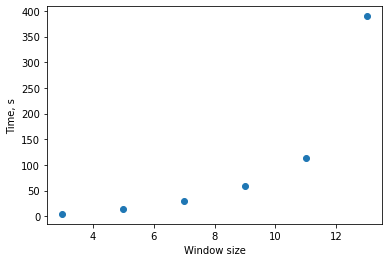

In [74]:
import matplotlib.pyplot as plt

plt.scatter([3, 5, 7, 9, 11, 13],
            [output_fast_1_time.average, output_fast_2_time.average,
             output_7.average, output_9.average,
             output_11.average, output_13.average
            ])
plt.xlabel('Window size')
plt.ylabel('Time, s')
plt.show()

Наблюдается квадратичная зависимость времени от размера окна 